In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_excel("EastWestAirlines.xlsx", sheet_name="data")
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [43]:
df.shape

(3999, 12)

In [44]:
#DataSet Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [45]:
#Summary Statistics
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [46]:
#Missing Values
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [47]:
#Duplicate Values
df.duplicated().sum()

np.int64(0)

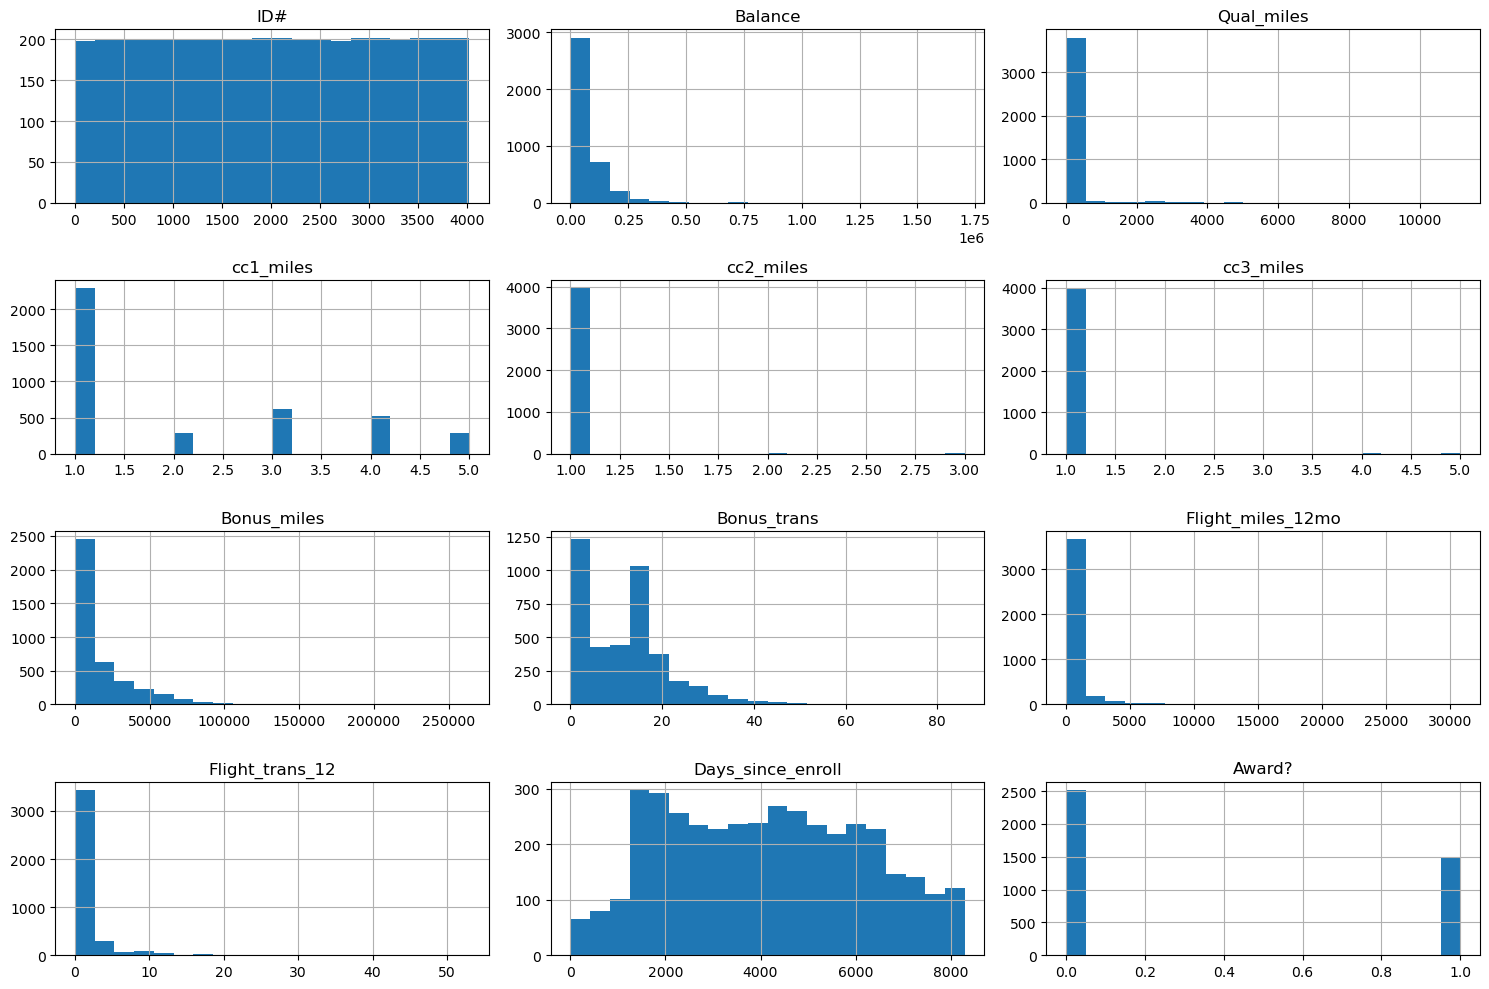

In [48]:
#Histograms
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

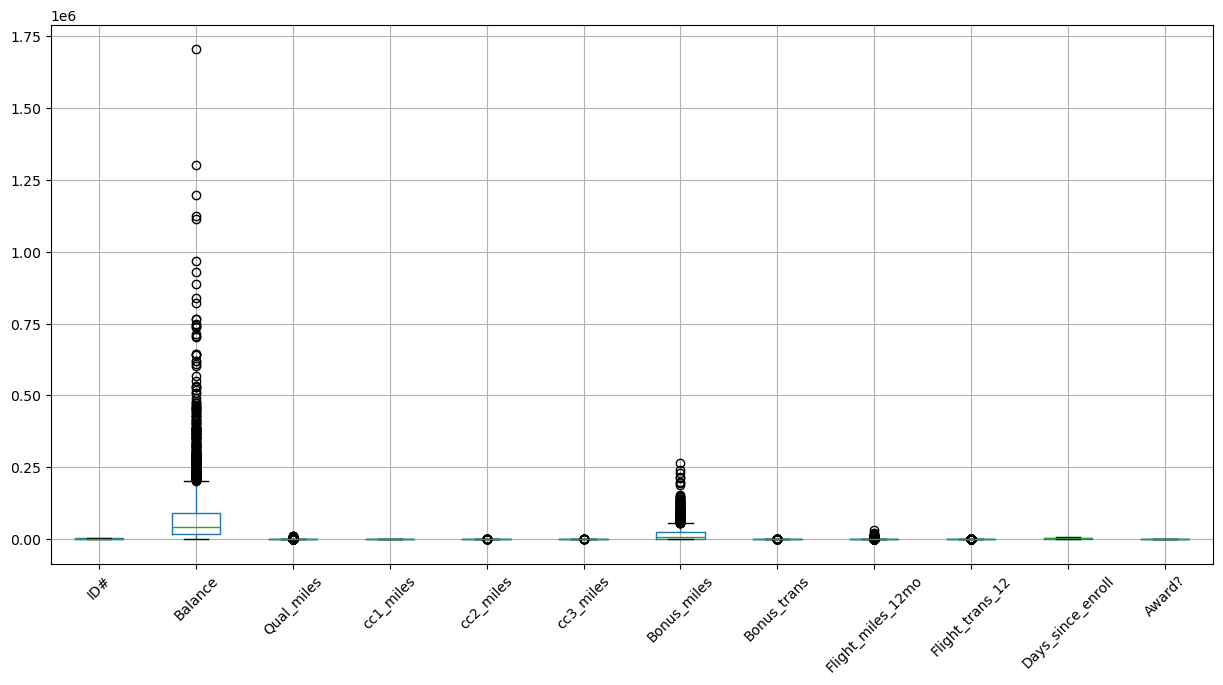

In [49]:
#Box Plots
plt.figure(figsize=(15,7))
df.boxplot()
plt.xticks(rotation=45)
plt.show()

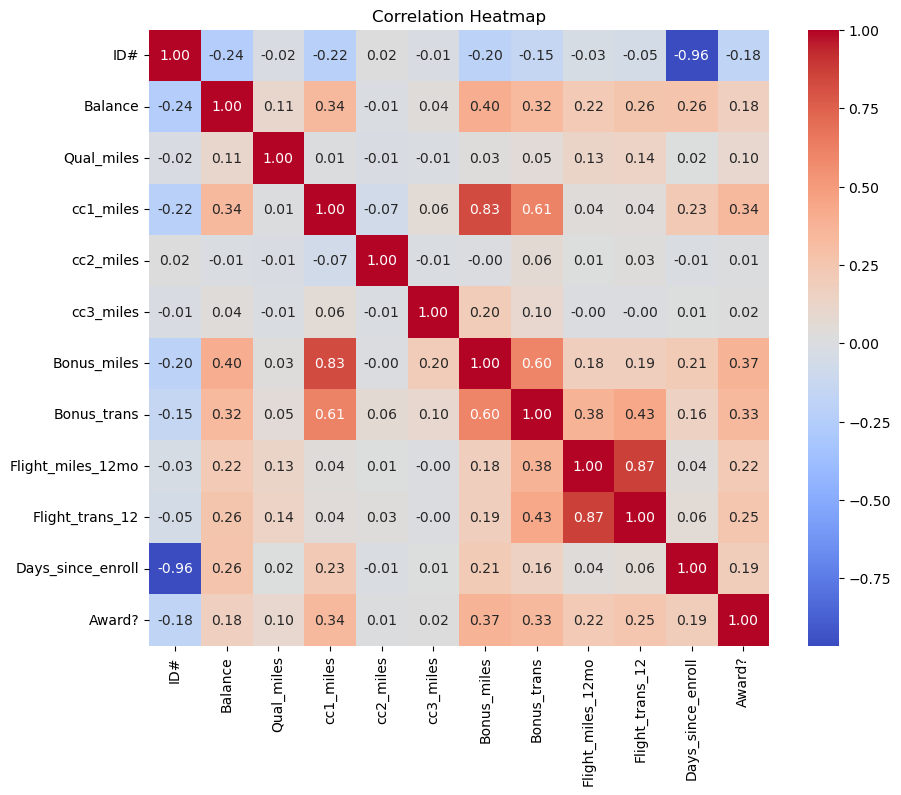

In [50]:
#Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [51]:
#Feature Scaling 
#Since both K-Means and DBSCAN are distance-based algorithms, scaling is required.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print(X_scaled.shape)

(3999, 12)


# TASK-2:Implementing Clustering Algorithms:

### Elbow Method

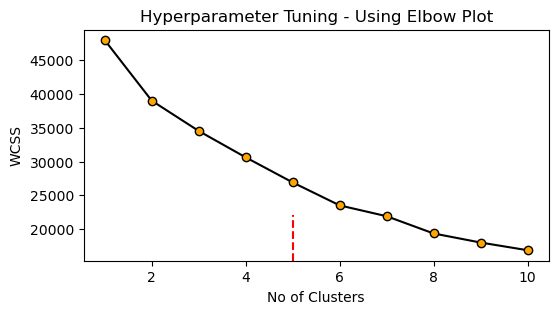

In [52]:
from sklearn.cluster import KMeans

WCSS = []

for i in range(1,11):
    model = KMeans(n_clusters=i,random_state=42,n_init=10
    )
    model.fit(X_scaled)
    WCSS.append(model.inertia_)

plt.figure(figsize=(6,3))
plt.title('Hyperparameter Tuning - Using Elbow Plot')
plt.xlabel('No of Clusters')
plt.ylabel('WCSS')

plt.plot(range(1,11),WCSS,marker='o',color='black',markerfacecolor='orange')

# Can replace 5 with your chosen K
plt.axvline(x=5, ymin=0, ymax=0.20, color='red', linestyle='--')

plt.show()

In [53]:
#Model Building
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

In [54]:
#Cluster Distribution
pd.Series(kmeans_labels).value_counts().sort_index()

0    1297
1    1532
2     139
3    1016
4      15
Name: count, dtype: int64

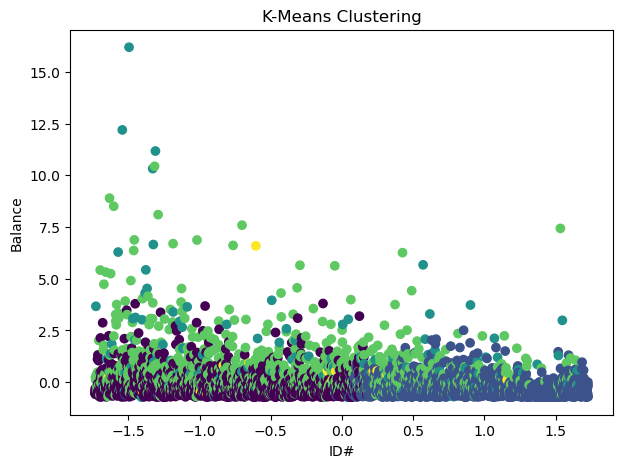

In [55]:
#scatter Plot
plt.figure(figsize=(7,5))
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=kmeans_labels,
    cmap='viridis'
)

plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title("K-Means Clustering")

plt.show()

In [56]:
#silhouette_score
from sklearn.metrics import silhouette_score

silhouette_kmeans = silhouette_score(X_scaled, kmeans_labels)
print("Silhouette Score:", round(silhouette_kmeans,3))

Silhouette Score: 0.239


# DBSCAN Clustering


In [57]:
#Build DBSCAN Model
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [58]:
#Cluster Distribution
pd.Series(dbscan_labels).value_counts().sort_index()   #-1 represents noise (outliers) detected by DBSCAN.

-1     352
 0    2404
 1    1216
 2      15
 3       8
 4       4
Name: count, dtype: int64

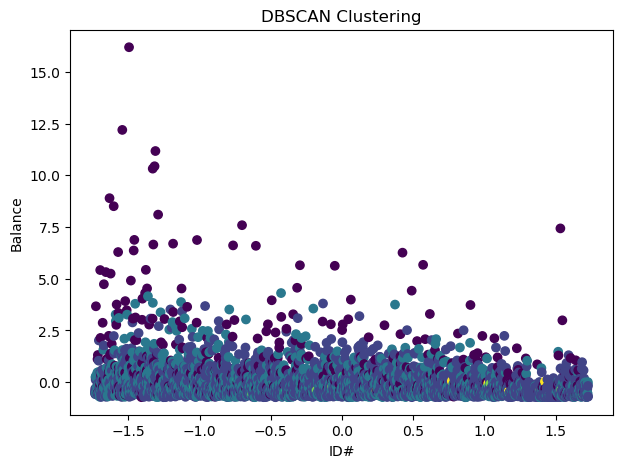

In [59]:
#Scatter Plot
plt.figure(figsize=(7,5))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=dbscan_labels,
    cmap='viridis'
)

plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title("DBSCAN Clustering")

plt.show()

In [73]:
# silhouette_score    
from sklearn.metrics import silhouette_score
import numpy as np

labels = dbscan_labels

if len(np.unique(labels)) > 2:
    score1= silhouette_score(X_scaled, labels)
    print("Silhouette Score:", round(score1,3))    #Calculate the score only if there are at least 2 clusters (excluding noise)
else:
    print("Silhouette Score cannot be calculated because only one cluster was found.")  

Silhouette Score: 0.19


## Hyperparameter Tuning for DBSCAN


In [67]:
#Trying different values of eps and min_samples.
# Choose the combination with the highest Silhouette Score.

In [68]:
eps_values = [0.5, 1.0, 1.5, 2.0]
min_samples_values = [3, 5, 7]

for eps in eps_values:
    for ms in min_samples_values:

        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)

        if len(set(labels)) > 2:
            score = silhouette_score(X_scaled, labels)
            print(f"eps={eps}, min_samples={ms}, Silhouette={score:.3f}")

eps=0.5, min_samples=3, Silhouette=-0.348
eps=0.5, min_samples=5, Silhouette=-0.282
eps=0.5, min_samples=7, Silhouette=-0.180
eps=1.0, min_samples=3, Silhouette=-0.094
eps=1.0, min_samples=5, Silhouette=0.144
eps=1.0, min_samples=7, Silhouette=0.123
eps=1.5, min_samples=3, Silhouette=0.173
eps=1.5, min_samples=5, Silhouette=0.190
eps=1.5, min_samples=7, Silhouette=0.212
eps=2.0, min_samples=3, Silhouette=0.210
eps=2.0, min_samples=5, Silhouette=0.211
eps=2.0, min_samples=7, Silhouette=0.224


In [70]:
# DBSCAN -Tuned Model building
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

dbscan2 = DBSCAN(eps=2.0,min_samples=7)
dbscan2_labels = dbscan2.fit_predict(X_scaled)

print(pd.Series(dbscan2_labels).value_counts().sort_index())

-1     235
 0    2440
 1    1300
 2      16
 3       8
Name: count, dtype: int64


In [71]:
#silhouette_score
from sklearn.metrics import silhouette_score
import numpy as np

if len(set(dbscan2_labels)) > 2:
    silhouette_dbscan2 = silhouette_score(X_scaled, dbscan2_labels)
    print("Silhouette Score:", round(silhouette_dbscan2,3))
else:
    print("Silhouette Score cannot be calculated.")

Silhouette Score: 0.224


In [74]:
# commparing 3 models
comparison = pd.DataFrame({
    'Algorithm': [
        'K-Means',
        'DBSCAN (eps=1.5, min_samples=5)',
        'DBSCAN (eps=2.0, min_samples=7)'
    ],
    'Silhouette Score': [
        silhouette_kmeans,
        score1,                  # First DBSCAN score
        silhouette_dbscan2      # Second DBSCAN score
    ]
})

comparison

,Algorithm,Silhouette Score
0,K-Means,0.239110
1,"DBSCAN (eps=1.5, min_samples=5)",0.189533
2,"DBSCAN (eps=2.0, min_samples=7)",0.223940


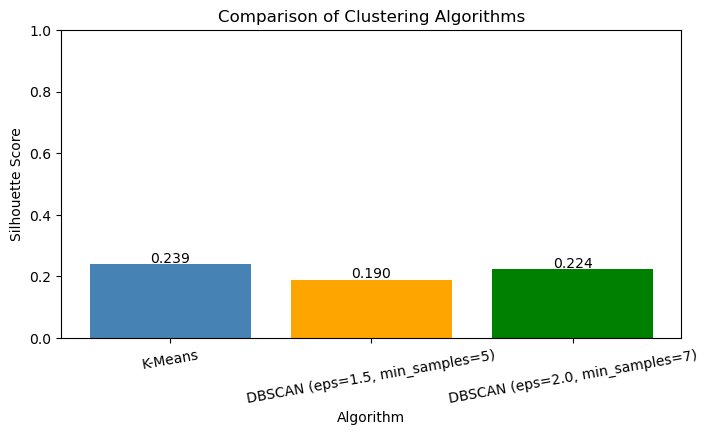

In [75]:
#Comparision Plot
plt.figure(figsize=(8,4))

plt.bar(
    comparison['Algorithm'],
    comparison['Silhouette Score'],
    color=['steelblue','orange','green']
)

plt.title("Comparison of Clustering Algorithms")
plt.xlabel("Algorithm")
plt.ylabel("Silhouette Score")

for i, v in enumerate(comparison['Silhouette Score']):
    plt.text(i, v+0.005, f"{v:.3f}", ha='center')

plt.ylim(0,1)
plt.xticks(rotation=10)

plt.show()

## Inference
- K-Means achieved the highest Silhouette Score, indicating the best cluster separation among the three models.
- The tuned DBSCAN model (eps=2.0, min_samples=7) produced a Silhouette Score of 0.224, showing moderate clustering performance.
- Based on the Silhouette Score, K-Means is the preferred clustering algorithm for this dataset.